# Evaluación de edad y género — 3 pipelines (UTKFace)

Proyecto AURA BUAP × IRIS UDLAP. Analiza el CSV de
`evaluacion/evaluar-edad-utkface.html` con los **tres** pipelines:

- **fa** = TinyFaceDetector→ageGenderNet (pipeline actual de producción)
- **hu** = @vladmandic/human
- **mesh** = FaceMesh→recorte→ageGenderNet (propuesta, mismo modelo de edad
  que "fa" pero alimentado por el detector más robusto de I1)

Incluye MAE/sesgo de edad (como antes) **y accuracy de género**, algo que no
habíamos medido hasta ahora.

```bash
source sentivision/bin/activate
pip install pandas numpy matplotlib scikit-learn
jupyter notebook
```


## 1. Carga y sanity checks

In [1]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.precision", 2)
plt.rcParams["figure.dpi"] = 110

candidatos = sorted(glob.glob("evaluacion_edad_genero_utkface_*.csv"))
if not candidatos:
    candidatos = sorted(glob.glob("**/evaluacion_edad_genero_utkface_*.csv", recursive=True))
assert candidatos, "No se encontró ningún evaluacion_edad_genero_utkface_*.csv"

CSV_PATH = candidatos[-1]
print("Usando:", CSV_PATH)
df = pd.read_csv(CSV_PATH)
df.head()


Usando: data/evaluacion_edad_genero_utkface_2026-07-16-11-14-00.csv


,archivo,edad_real,genero_real,edad_faceapi,genero_faceapi,error_faceapi,edad_human,genero_human,error_human,edad_mesh,genero_mesh,error_mesh
0,55_0_3_20170119211432745.jpg.chip.jpg,55,male,NaN,NaN,NaN,49.3,male,-5.7,57.54,male,2.54
1,68_0_0_20170117172902192.jpg.chip.jpg,68,male,74.23,male,6.23,69.1,NaN,1.1,68.17,male,0.17
2,58_0_0_20170111204009616.jpg.chip.jpg,58,male,59.55,male,1.55,69.1,male,11.1,56.67,male,-1.33
3,20_1_0_20170103175447799.jpg.chip.jpg,20,female,NaN,NaN,NaN,28.7,female,8.7,34.27,female,14.27
4,22_0_0_20170117134610684.jpg.chip.jpg,22,male,NaN,NaN,NaN,28.6,male,6.6,24.12,male,2.12


In [2]:
print("Filas:", len(df))
print("\nNulos por columna:")
print(df.isna().sum())


Filas: 3000

Nulos por columna:
archivo              0
edad_real            0
genero_real          0
edad_faceapi      2007
genero_faceapi    2007
error_faceapi     2007
edad_human         189
genero_human       133
error_human        189
edad_mesh           43
genero_mesh         43
error_mesh          43
dtype: int64


In [3]:
BINS = [(0, 12), (13, 19), (20, 29), (30, 39), (40, 49), (50, 59), (60, 999)]
BIN_LABELS = [f"{lo}-{hi if hi < 999 else '+'}" for lo, hi in BINS]

def bin_label(age):
    for lo, hi in BINS:
        if lo <= age <= hi:
            return f"{lo}-{hi if hi < 999 else '+'}"
    return None

df["rango"] = pd.Categorical(df["edad_real"].apply(bin_label), categories=BIN_LABELS, ordered=True)
ENGINES = {"fa": "face-api", "hu": "Human", "mesh": "FaceMesh→recorte"}
df.head()


,archivo,edad_real,genero_real,edad_faceapi,genero_faceapi,error_faceapi,edad_human,genero_human,error_human,edad_mesh,genero_mesh,error_mesh,rango
0,55_0_3_20170119211432745.jpg.chip.jpg,55,male,NaN,NaN,NaN,49.3,male,-5.7,57.54,male,2.54,50-59
1,68_0_0_20170117172902192.jpg.chip.jpg,68,male,74.23,male,6.23,69.1,NaN,1.1,68.17,male,0.17,60-+
2,58_0_0_20170111204009616.jpg.chip.jpg,58,male,59.55,male,1.55,69.1,male,11.1,56.67,male,-1.33,50-59
3,20_1_0_20170103175447799.jpg.chip.jpg,20,female,NaN,NaN,NaN,28.7,female,8.7,34.27,female,14.27,20-29
4,22_0_0_20170117134610684.jpg.chip.jpg,22,male,NaN,NaN,NaN,28.6,male,6.6,24.12,male,2.12,20-29


## 2. Tasa de detección por pipeline

In [4]:
det = df.groupby("rango", observed=True).agg(
    n=("edad_real", "size"),
    fa=("edad_faceapi", lambda s: s.notna().mean() * 100),
    hu=("edad_human", lambda s: s.notna().mean() * 100),
    mesh=("edad_mesh", lambda s: s.notna().mean() * 100),
).round(1)

col_map = {"fa": "edad_faceapi", "hu": "edad_human", "mesh": "edad_mesh"}
print("Detección global:", {k: round(df[col_map[k]].notna().mean() * 100, 1) for k in ["fa", "hu", "mesh"]})
det


Detección global: {'fa': np.float64(33.1), 'hu': np.float64(93.7), 'mesh': np.float64(98.6)}


,n,fa,hu,mesh
rango,,,,
0-12,436,52.8,56.9,98.4
13-19,138,47.8,100.0,99.3
20-29,941,29.1,100.0,98.4
30-39,572,25.9,100.0,99.0
40-49,301,27.2,100.0,98.7
50-59,274,29.6,100.0,98.5
60-+,338,33.1,99.7,98.2


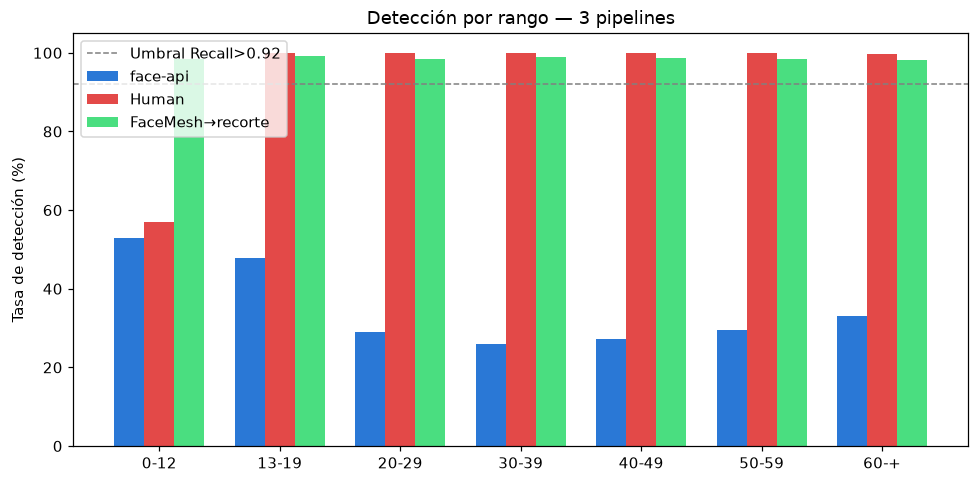

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(det))
width = 0.25
colors = {"fa": "#2a78d6", "hu": "#e34948", "mesh": "#4ade80"}
for i, eng in enumerate(["fa", "hu", "mesh"]):
    ax.bar(x + (i-1)*width, det[eng], width, label=ENGINES[eng], color=colors[eng])
ax.axhline(92, color="gray", linestyle="--", linewidth=1, label="Umbral Recall>0.92")
ax.set_xticks(x); ax.set_xticklabels(det.index)
ax.set_ylabel("Tasa de detección (%)")
ax.set_title("Detección por rango — 3 pipelines")
ax.legend()
plt.tight_layout(); plt.show()


## 3. MAE y sesgo de edad (comparación pareja: los 3 detectaron)

Solo sobre filas donde los tres pipelines detectaron la misma imagen —
comparación justa entre los tres.


In [6]:
paired = df.dropna(subset=["edad_faceapi", "edad_human", "edad_mesh"]).copy()
for eng, col in [("fa", "faceapi"), ("hu", "human"), ("mesh", "mesh")]:
    paired[f"error_{eng}"] = paired[f"edad_{col}"] - paired["edad_real"]

print(f"Filas pareadas (los 3 detectaron): {len(paired)} de {len(df)}")

def mae(s): return s.abs().mean()
def rmse(s): return np.sqrt((s**2).mean())

resumen = pd.DataFrame({
    "MAE": [mae(paired[f"error_{e}"]) for e in ["fa","hu","mesh"]],
    "RMSE": [rmse(paired[f"error_{e}"]) for e in ["fa","hu","mesh"]],
    "Sesgo medio": [paired[f"error_{e}"].mean() for e in ["fa","hu","mesh"]],
}, index=[ENGINES[e] for e in ["fa","hu","mesh"]])
resumen


Filas pareadas (los 3 detectaron): 881 de 3000


,MAE,RMSE,Sesgo medio
face-api,4.90,6.69,-0.17
Human,8.36,12.08,-3.01
FaceMesh→recorte,4.78,6.54,-0.61


In [7]:
por_rango = paired.groupby("rango", observed=True).agg(
    n=("edad_real", "size"),
    mae_fa=("error_fa", mae), mae_hu=("error_hu", mae), mae_mesh=("error_mesh", mae),
    sesgo_fa=("error_fa", "mean"), sesgo_hu=("error_hu", "mean"), sesgo_mesh=("error_mesh", "mean"),
).round(2)
por_rango


,n,mae_fa,mae_hu,mae_mesh,sesgo_fa,sesgo_hu,sesgo_mesh
rango,,,,,,,
0-12,121,1.92,5.52,1.86,0.20,5.06,0.30
13-19,66,3.83,8.88,3.43,0.73,7.39,0.62
20-29,273,4.33,3.84,4.31,0.30,1.78,0.17
30-39,148,6.31,5.04,5.81,-0.11,-2.88,-0.45
40-49,82,7.00,9.92,6.49,1.11,-8.15,-0.25
50-59,81,5.94,15.42,5.72,0.16,-12.10,-1.19
60-+,110,6.01,20.47,6.58,-3.52,-19.65,-4.34


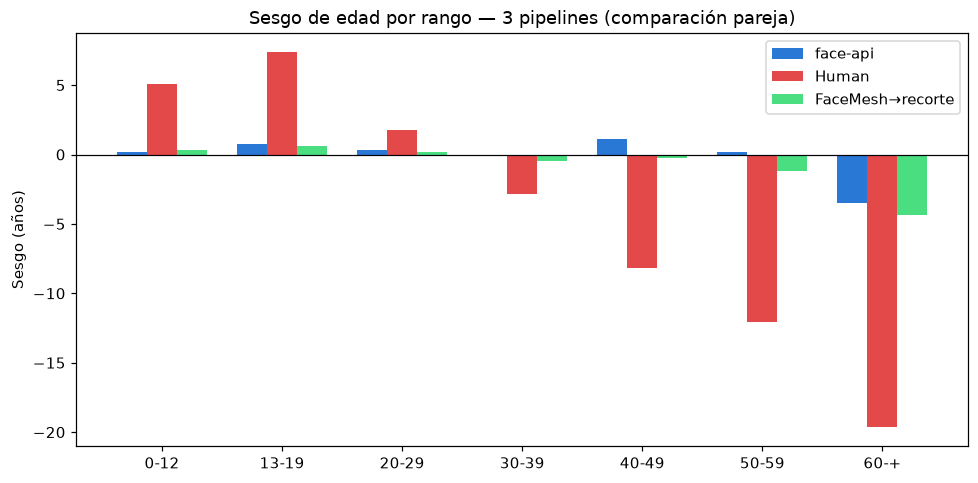

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(por_rango))
width = 0.25
for i, eng in enumerate(["fa", "hu", "mesh"]):
    ax.bar(x + (i-1)*width, por_rango[f"sesgo_{eng}"], width, label=ENGINES[eng], color=colors[eng])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(por_rango.index)
ax.set_ylabel("Sesgo (años)")
ax.set_title("Sesgo de edad por rango — 3 pipelines (comparación pareja)")
ax.legend()
plt.tight_layout(); plt.show()


## 4. ¿La propuesta (mesh) mejora sobre el pipeline actual (fa)?

Comparación directa cabeza a cabeza, ignorando Human — es la pregunta que
más importa para decidir si integrar el cambio a `app.js`.


In [9]:
mejora = paired["error_fa"].abs() - paired["error_mesh"].abs()
print(f"En {(mejora > 0).mean()*100:.1f}% de las imágenes, mesh tuvo MENOS error que fa")
print(f"En {(mejora < 0).mean()*100:.1f}% de las imágenes, fa tuvo menos error que mesh")
print(f"Diferencia promedio (fa_error_abs - mesh_error_abs): {mejora.mean():+.2f} años (positivo = mesh gana)")


En 52.4% de las imágenes, mesh tuvo MENOS error que fa
En 47.2% de las imágenes, fa tuvo menos error que mesh
Diferencia promedio (fa_error_abs - mesh_error_abs): +0.12 años (positivo = mesh gana)


## 5. Accuracy de género

In [10]:
def gender_acc(sub, col_pred):
    s = sub.dropna(subset=[col_pred])
    if len(s) == 0:
        return None, 0
    return (s[col_pred] == s["genero_real"]).mean() * 100, len(s)

print("Accuracy de género global (sobre todas las detecciones, no solo pareadas):")
for eng, col in [("fa", "genero_faceapi"), ("hu", "genero_human"), ("mesh", "genero_mesh")]:
    acc, n = gender_acc(df, col)
    print(f"  {ENGINES[eng]:20s}: {acc:.1f}%  (n={n})" if acc is not None else f"  {ENGINES[eng]}: sin datos")


Accuracy de género global (sobre todas las detecciones, no solo pareadas):
  face-api            : 91.3%  (n=993)
  Human               : 88.2%  (n=2867)
  FaceMesh→recorte    : 93.9%  (n=2957)


In [11]:
gender_por_rango = df.groupby("rango", observed=True).apply(
    lambda g: pd.Series({
        "n": len(g),
        "acc_fa": gender_acc(g, "genero_faceapi")[0],
        "acc_hu": gender_acc(g, "genero_human")[0],
        "acc_mesh": gender_acc(g, "genero_mesh")[0],
    }),
    include_groups=False,
).round(1)
gender_por_rango


,n,acc_fa,acc_hu,acc_mesh
rango,,,,
0-12,436.0,75.7,60.6,76.9
13-19,138.0,95.5,87.7,94.2
20-29,941.0,97.1,94.6,96.8
30-39,572.0,95.3,93.2,96.6
40-49,301.0,92.7,92.8,96.6
50-59,274.0,98.8,95.1,98.1
60-+,338.0,95.5,85.1,97.3


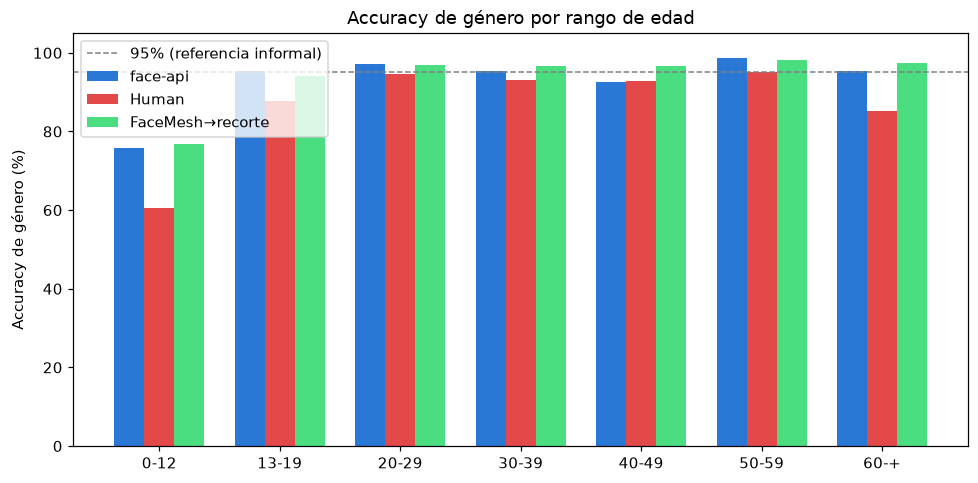

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(gender_por_rango))
width = 0.25
for i, eng in enumerate(["fa", "hu", "mesh"]):
    ax.bar(x + (i-1)*width, gender_por_rango[f"acc_{eng}"], width, label=ENGINES[eng], color=colors[eng])
ax.axhline(95, color="gray", linestyle="--", linewidth=1, label="95% (referencia informal)")
ax.set_xticks(x); ax.set_xticklabels(gender_por_rango.index)
ax.set_ylabel("Accuracy de género (%)")
ax.set_ylim(0, 105)
ax.set_title("Accuracy de género por rango de edad")
ax.legend()
plt.tight_layout(); plt.show()


## 6. Conclusión (completar tras correr)

- Detección global: fa ___%, hu ___%, mesh ___%
- MAE pareado: fa ___, hu ___, mesh ___
- ¿mesh mejora sobre fa en la mayoría de las imágenes? ___
- Accuracy de género: fa ___%, hu ___%, mesh ___%
- ¿El género resultó tan robusto como se esperaba, o hay algún rango de edad
  donde cae notablemente (adolescentes/niños son un sospechoso típico)? ___
- **Decisión sobre integrar `mesh` a `app.js`:** ___
